In [53]:
import datetime, os
import random, pandas as pd, numpy as np, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import img_to_array, load_img

In [2]:
physical_devices = tf.config.list_physical_devices('GPU')
tf.config.experimental.set_memory_growth(physical_devices[0], True)

gpu_options = tf.compat.v1.GPUOptions(allow_growth=True)
config = tf.compat.v1.ConfigProto(gpu_options=gpu_options)
session = tf.compat.v1.Session(config=config)

In [3]:
# Hyperparameters
IMAGE_SIZE = 224
BATCH_SIZE = 32
TRAIN_RATIO = 0.8; VAL_RATIO = 1 - TRAIN_RATIO
LEARNING_RATE = 0.0001
DROPOUT_PROB = 0.3
NUM_EPOCHS = 50
PATIENCE = 5 # patience for early stopping
LR_PATIENCE = 5 # patience for learning rate scheduler

In [4]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(directory=r'C:\Users\miola1\Downloads\ddd\Driver Drowsiness Dataset (DDD)',
                                                            validation_split=VAL_RATIO,
                                                            subset='training',
                                                            image_size=(IMAGE_SIZE, IMAGE_SIZE),
                                                            batch_size=BATCH_SIZE,
                                                            seed=42,
                                                            labels='inferred',
                                                            label_mode='int')

val_ds = tf.keras.preprocessing.image_dataset_from_directory(directory=r'C:\Users\miola1\Downloads\ddd\Driver Drowsiness Dataset (DDD)',
                                                          validation_split=VAL_RATIO,
                                                          subset="validation",
                                                          image_size=(IMAGE_SIZE, IMAGE_SIZE),
                                                          batch_size=BATCH_SIZE,
                                                          seed=42,
                                                          labels='inferred',
                                                          label_mode='int')

Found 41793 files belonging to 2 classes.
Using 33435 files for training.
Found 41793 files belonging to 2 classes.
Using 8358 files for validation.


In [5]:
class_names = train_ds.class_names
print(class_names)

['Drowsy', 'Non Drowsy']


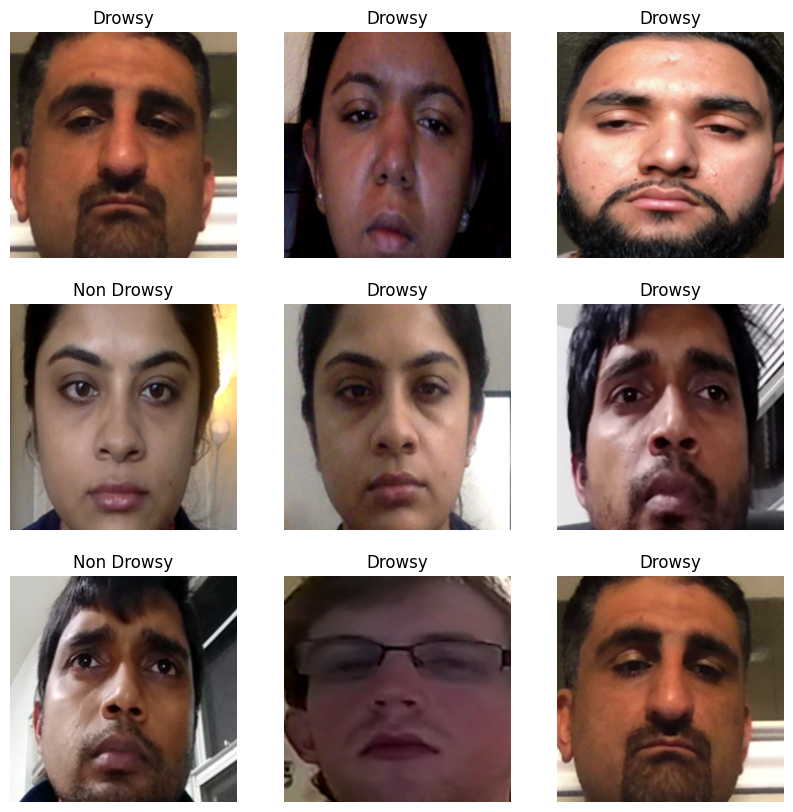

In [6]:
# Sample viz
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis('off')

In [7]:
for image_batch, labels_batch in train_ds:
  print(image_batch.shape)
  print(labels_batch.shape)
  break

(32, 224, 224, 3)
(32,)


In [8]:
print(f"Total batches >> train: {len(train_ds)} and validation: {len(val_ds)}")

Total batches >> train: 1045 and validation: 262


In [9]:
def stacked_model(input_shape=[IMAGE_SIZE, IMAGE_SIZE, 3], output_shape=len(class_names)):

  mobilenet = tf.keras.applications.MobileNetV2(weights='imagenet',
                                                include_top=False,
                                                input_shape=input_shape)

  efficientnet = tf.keras.applications.EfficientNetV2B3(weights='imagenet',
                                                      include_top=False,
                                                      input_shape=input_shape)

  # Freeze pre-trained models
  mobilenet.trainable = False
  efficientnet.trainable = False

  # Input layer
  inputs = tf.keras.Input(shape=input_shape)

  # Apply data augmentation
  data_augmentation = tf.keras.Sequential([
      tf.keras.layers.RandomFlip("horizontal"),
      tf.keras.layers.RandomRotation(0.2)
  ])

  augmented_inputs = data_augmentation(inputs)

  # Extracted features
  mobilenet_features = mobilenet(augmented_inputs)
  efficientnet_features = efficientnet(augmented_inputs)

  # Global avg pooling instead of flatten
  mobilenet_pooling = tf.keras.layers.GlobalAveragePooling2D()(mobilenet_features)
  efficientnet_pooling = tf.keras.layers.GlobalAveragePooling2D()(efficientnet_features)

  # Concatenate features
  concatenated_features = tf.keras.layers.concatenate([mobilenet_pooling, efficientnet_pooling])

  # Dense layers
  x = tf.keras.layers.Dense(1024, activation='relu')(concatenated_features)
  x = tf.keras.layers.Dropout(DROPOUT_PROB)(x)
  outputs = tf.keras.layers.Dense(output_shape, activation='softmax')(x)

  model = tf.keras.Model(inputs=inputs, outputs=outputs)

  model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
                metrics=["accuracy"])
  return model

In [10]:
# Model summary
model = stacked_model()
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_3 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 sequential (Sequential)        (None, 224, 224, 3)  0           ['input_3[0][0]']                
                                                                                                  
 mobilenetv2_1.00_224 (Function  (None, 7, 7, 1280)  2257984     ['sequential[0][0]']             
 al)                                                                                              
                                                                                              

In [11]:
# Defining Tensorboard, early stopping, and learning rate scheduler

def create_tb_callback():
  logdir = os.path.join('logs', datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
  return tf.keras.callbacks.TensorBoard(logdir)

early_stopping = tf.keras.callbacks.EarlyStopping(monitor='accuracy', patience=PATIENCE)
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(monitor='accuracy', factor=0.2, patience=LR_PATIENCE)

In [12]:
# Training the model

with tf.device('/GPU:0'):
  def train_model():
    model = stacked_model()
    tensorboard = create_tb_callback()
    model.fit(train_ds, validation_data=val_ds, epochs=NUM_EPOCHS, callbacks=[tensorboard, early_stopping, lr_scheduler], shuffle=True)
    return model

In [14]:
# predictions = model.predict(val_ds, verbose=1)

In [15]:
# Save and Load Model
def save_model(model, suffix=None):
    model_dir = os.path.join("models", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
    model_path = model_dir + (suffix if suffix else "") + ".h5"
    print("Saving model to", model_path + "...")
    model.save(model_path)
    return model_path

def load_model(model_path):
    print("Loading model from:", model_path)
    model = tf.keras.models.load_model(model_path)
    return model

In [16]:
aayam_model = stacked_model()
model_tb = create_tb_callback()
model_early_stopping = tf.keras.callbacks.EarlyStopping(monitor='accuracy', patience=10)
history = aayam_model.fit(train_ds, epochs=NUM_EPOCHS, callbacks=[model_tb, model_early_stopping])
save_model(aayam_model, suffix='train_data')

Epoch 1/50
1045/1045 [==============================] - 324s 296ms/step - loss: 0.1493 - accuracy: 0.9466
Epoch 2/50
1045/1045 [==============================] - 304s 291ms/step - loss: 0.0281 - accuracy: 0.9934
Epoch 3/50
1045/1045 [==============================] - 304s 291ms/step - loss: 0.0157 - accuracy: 0.9965
Epoch 4/50
1045/1045 [==============================] - 304s 291ms/step - loss: 0.0106 - accuracy: 0.9973
Epoch 5/50
1045/1045 [==============================] - 302s 289ms/step - loss: 0.0108 - accuracy: 0.9971
Epoch 6/50
1045/1045 [==============================] - 302s 289ms/step - loss: 0.0071 - accuracy: 0.9983
Epoch 7/50
1045/1045 [==============================] - 302s 289ms/step - loss: 0.0056 - accuracy: 0.9983
Epoch 8/50
1045/1045 [==============================] - 303s 290ms/step - loss: 0.0052 - accuracy: 0.9986
Epoch 9/50
1045/1045 [==============================] - 303s 290ms/step - loss: 0.0048 - accuracy: 0.9987
Epoch 10/50
1045/1045 [=======================

'models\\20250612-184758train_data.h5'

In [20]:
history = aayam_model.history.history

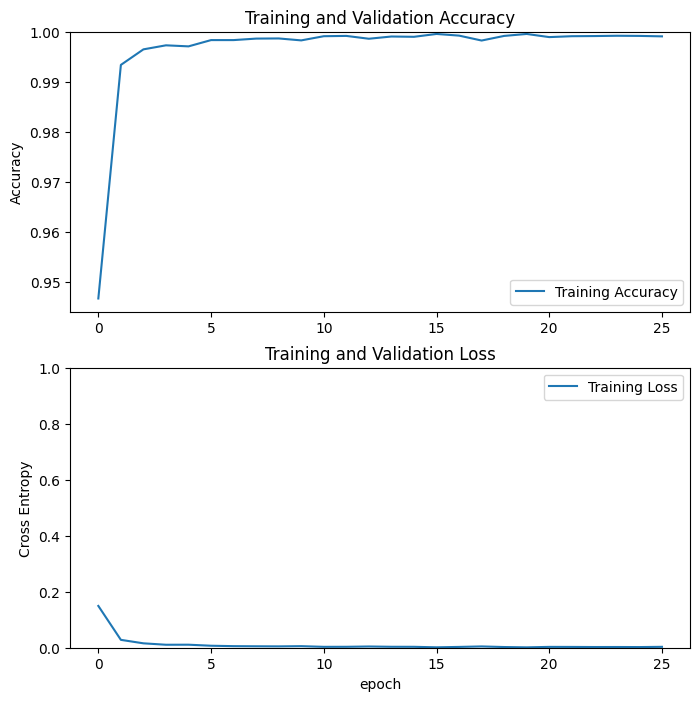

In [52]:
acc = history['accuracy']
loss = history['loss']
plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0,1.0])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

## Testing time !!!

1/1 [==============================] - 0s 26ms/step


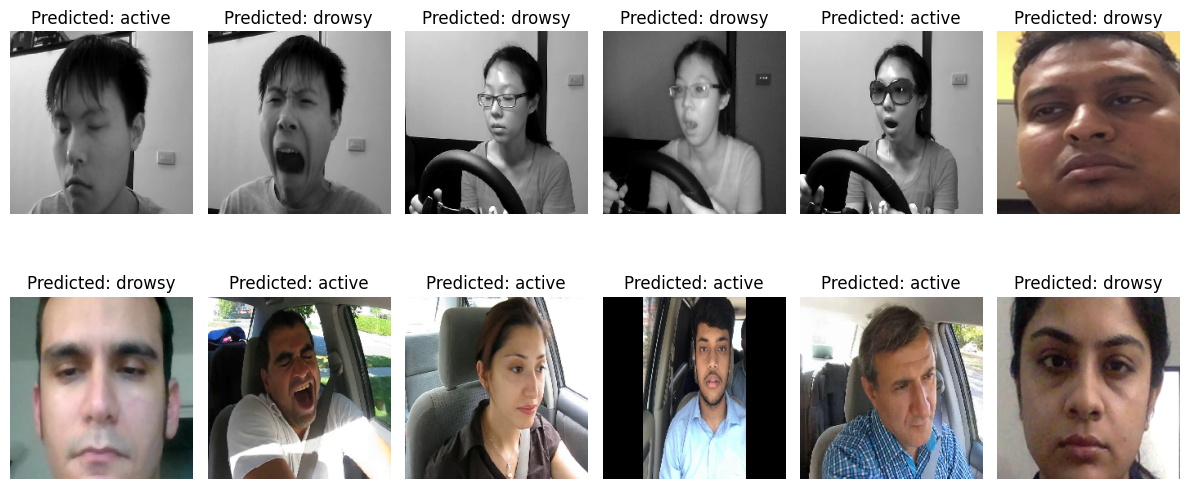

In [75]:
model = load_model('models\\20250612-184758train_data.h5')
test_dir = r'aayam_test'; predictions = []
plt.figure(figsize=(12, 6))
counter = 1

for img_file in os.listdir(test_dir):
    if img_file.endswith(('.png', '.jpg', '.jpeg')):
        img_path = os.path.join(test_dir, img_file)
        image_OG = load_img(img_path, target_size=(224, 224))
        img_array = img_to_array(image_OG)
        img_array = np.expand_dims(img_array, axis=0)
        preds = model.predict(img_array)
        pred_class = np.argmax(preds); drowsiness_state = "active" if pred_class == 1 else "drowsy"
        predictions.append((img_file, pred_class))
        plt.subplot(2, 6, counter)
        plt.imshow(image_OG)
        plt.title(f"Predicted: {drowsiness_state}")
        plt.axis('off')
        counter += 1
plt.tight_layout()
plt.savefig("output.png", dpi=300)
plt.show()